In [1]:
# ── 0. Clear Python cache (run this first if you just did git pull) ───
import shutil, pathlib
removed = 0
for p in pathlib.Path('.').rglob('__pycache__'):
    shutil.rmtree(p, ignore_errors=True)
    removed += 1
for p in pathlib.Path('.').rglob('*.pyc'):
    p.unlink(missing_ok=True)
    removed += 1
print(f'Cleared {removed} cache entries — fresh code will be loaded.')


Cleared 0 cache entries — fresh code will be loaded.


# AI-Powered Bird Call Detection — ML Extension
### Complete pipeline: data → augmentation → two-phase training → K-fold CV → evaluation → ONNX export


In [2]:
# ── 0. Setup paths & imports ──────────────────────────────────────────
import sys, os
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent  # adjust if notebook is in notebooks/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings; warnings.filterwarnings('ignore')
import yaml, json, time, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split

logging.basicConfig(level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(name)s | %(message)s')
logger = logging.getLogger('notebook')

# ── Load config ────────────────────────────────────────────────────────
CONFIG_PATH = PROJECT_ROOT / 'config' / 'config.yaml'
with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

# ── Derived constants ─────────────────────────────────────────────────
all_species = (config['species']['target_species'] +
               config['species']['background_species'])
CLASS_NAMES = [sp['common_name'] for sp in
               sorted(all_species, key=lambda x: x['class_id'])]
NUM_CLASSES = len(CLASS_NAMES)

print(f'PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')
print(f'Config loaded from: {CONFIG_PATH}')
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')


PyTorch 2.8.0+cpu | CUDA: False
Config loaded from: C:\Users\JAMI SAI AKSHAYA\Bird_Call_Detection\config\config.yaml
Classes (9): ['Whooping Crane', 'California Condor', 'Ivory-billed Woodpecker', 'Attwater Prairie-chicken', 'Loggerhead Shrike', 'American Robin', 'American Crow', 'Northern Cardinal', 'Carolina Chickadee']


In [3]:
# ── 1. Verify API connectivity (v3) ──────────────────────────────────
import requests

KEY  = config['xeno_canto']['api_key']
URL  = 'https://xeno-canto.org/api/3/recordings'

try:
    resp = requests.get(
        URL,
        params={'query': 'gen:Turdus sp:migratorius', 'page': 1, 'key': KEY},
        headers={'User-Agent': 'Mozilla/5.0 BirdResearch/3.0'},
        timeout=10)
    if resp.status_code == 200:
        n = resp.json().get('numRecordings', '?')
        print(f'✓ Xeno-Canto API v3 reachable  (American Robin → {n} recordings)')
    else:
        print(f'✗ API returned HTTP {resp.status_code} — URL: {resp.url}')
        print('  Possible causes: wrong api_key, or no internet.')
        print(f'  Response body: {resp.text[:300]}')
except Exception as e:
    print(f'✗ Cannot reach Xeno-Canto: {e}')


✓ Xeno-Canto API v3 reachable  (American Robin → 950 recordings)


In [4]:
# ── 2. Data collection via Xeno-Canto ────────────────────────────────
import importlib, src.data.xeno_canto_api
importlib.reload(src.data.xeno_canto_api)   # pick up latest code after git pull
from src.data.xeno_canto_api import XenoCantoAPI
from src.data.dataset import build_multiclass_dataframe

api = XenoCantoAPI(config)
print(f'API base URL : {api.base_url}')
print(f'API key set  : {bool(api.api_key)}')

# ── Collect target species ───────────────────────────────────────────
target_recordings = []
for sp in config['species']['target_species']:
    # Pass scientific name only — XenoCantoAPI._build_query() converts it
    # to gen:Genus sp:species format automatically (required by v3).
    recs = api.search_recordings(
        sp['scientific_name'],
        max_results=config['xeno_canto']['recordings_per_species'])
    for r in recs:
        r['target_species'] = sp['scientific_name']
        r['common_name']    = sp['common_name']
        r['class_id']       = sp['class_id']
    target_recordings.extend(recs)
    print(f"  {sp['common_name']}: {len(recs)} recordings")

# ── Collect background species ───────────────────────────────────────
bg_recordings = []
bg_per = max(50, config['xeno_canto']['recordings_per_species'] // 2)
for sp in config['species']['background_species']:
    recs = api.search_recordings(sp['scientific_name'], max_results=bg_per)
    for r in recs:
        r['target_species'] = sp['scientific_name']
        r['common_name']    = sp['common_name']
        r['class_id']       = sp['class_id']
    bg_recordings.extend(recs)
    print(f"  {sp['common_name']} (bg): {len(recs)} recordings")

# ── Build dataframe ──────────────────────────────────────────────────
all_recs = target_recordings + bg_recordings

if len(all_recs) == 0:
    raise RuntimeError(
        '\n\nNo recordings collected. Possible causes:\n'
        '  1. Internet/VPN blocking xeno-canto.org\n'
        '  2. Invalid or expired api_key in config.yaml\n'
        '  3. Old .pyc files — run the cache-clear cell at the top\n'
    )

raw_df  = pd.DataFrame(all_recs)
full_df = build_multiclass_dataframe(
    raw_df,
    config['species']['target_species'],
    config['species']['background_species'])

print(f'\nTotal recordings: {len(full_df)}')
print('Class distribution:')
dist = full_df['label'].value_counts().sort_index()
for lbl, cnt in dist.items():
    name = CLASS_NAMES[lbl] if lbl < len(CLASS_NAMES) else str(lbl)
    print(f'  [{lbl}] {name:<35} {cnt}')


2026-04-30 17:06:40,276 | INFO | src.data.xeno_canto_api | XenoCantoAPI ready  url=https://xeno-canto.org/api/3/recordings


API base URL : https://xeno-canto.org/api/3/recordings
API key set  : True


Fetching: Grus americana: 0rec [00:00, ?rec/s]

2026-04-30 17:06:40,972 | INFO | src.data.xeno_canto_api | Got 3 recordings for "Grus americana"


  Whooping Crane: 3 recordings


...

2026-04-30 17:06:56,083 | INFO | src.data.xeno_canto_api | Got 250 recordings for "Cardinalis cardinalis"


  Northern Cardinal (bg): 250 recordings


Fetching: Poecile carolinensis: 0rec [00:00, ?rec/s]

2026-04-30 17:06:58,945 | INFO | src.data.xeno_canto_api | Got 250 recordings for "Poecile carolinensis"


  Carolina Chickadee (bg): 250 recordings

Total recordings: 1279
Class distribution:
  [0] Whooping Crane                      3
  [2] Ivory-billed Woodpecker             6
  [3] Attwater Prairie-chicken            51
  [4] Loggerhead Shrike                   219
  [5] American Robin                      250
  [6] American Crow                       250
  [7] Northern Cardinal                   250
  [8] Carolina Chickadee                  250


In [5]:
# ── 3. Download audio files ───────────────────────────────────────────
download_dir = Path(config['paths']['raw_audio_dir'])
downloaded_df = api.batch_download_audio(full_df, download_dir, max_workers=3)
# keep only successfully downloaded
downloaded_df = downloaded_df[downloaded_df['download_success'] == True].copy()
downloaded_df = downloaded_df[downloaded_df['local_path'].notna()].copy()
print(f'Downloaded: {len(downloaded_df)} files')
print(downloaded_df['label'].value_counts().to_string())

2026-04-30 17:32:13,075 | INFO | src.data.xeno_canto_api | Downloaded 1279/1279 files


Downloaded: 1279 files
label
8    250
7    250
6    250
5    250
4    219
3     51
2      6
0      3


2026-04-30 17:32:24,220 | INFO | src.data.audio_processor | AudioProcessor — sr=32000 dur=5.0s n_mels=128


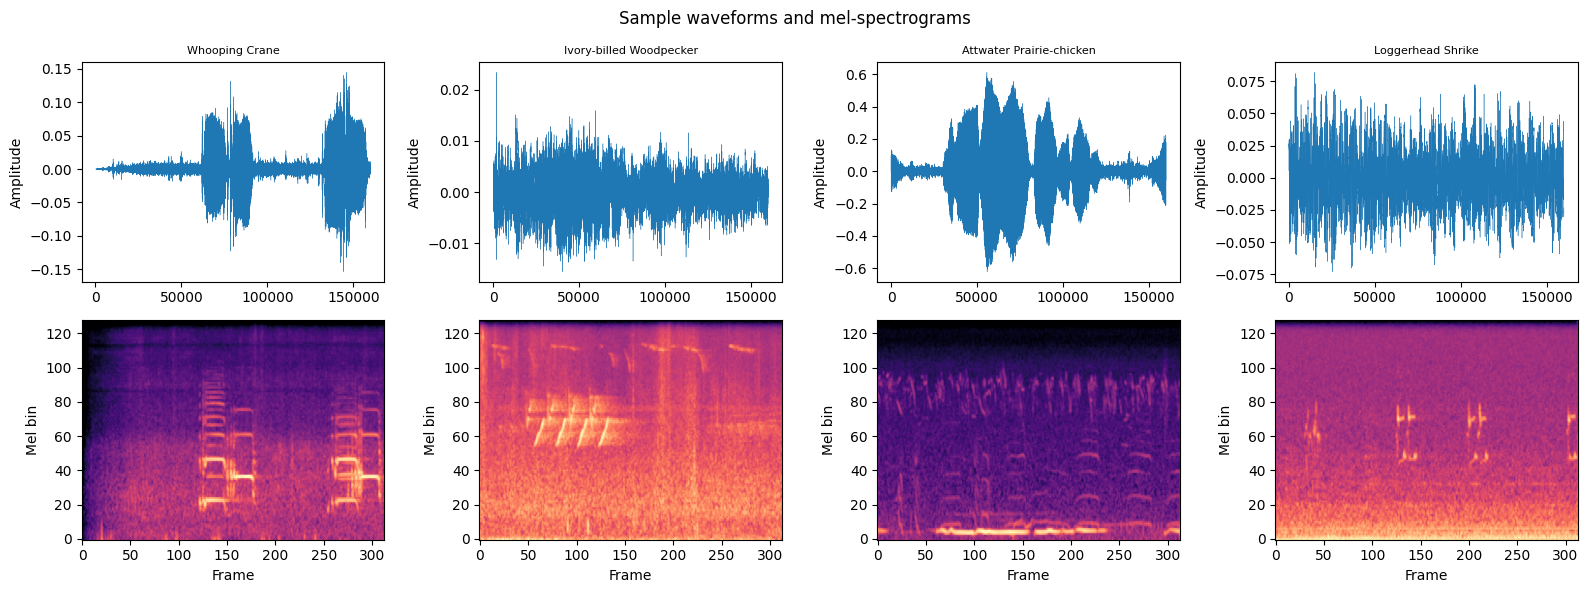

In [6]:
# ── 4. Audio processor + sample visualisation ────────────────────────
from src.data.audio_processor import AudioProcessor

audio_proc = AudioProcessor(config)

# visualise one sample per class
sample_paths = (
    downloaded_df.groupby('label')
    .first()
    .reset_index()[['label','local_path','common_name']]
)

fig, axes = plt.subplots(2, min(4, len(sample_paths)), figsize=(16, 6))
for i, (_, row) in enumerate(sample_paths.iterrows()):
    if i >= 4: break
    ax_wave, ax_mel = axes[0, i], axes[1, i]
    audio = audio_proc.load_audio(row['local_path'])
    mel   = audio_proc.compute_mel_spectrogram(audio)
    ax_wave.plot(audio, linewidth=0.3)
    ax_wave.set_title(row['common_name'], fontsize=8)
    ax_wave.set_ylabel('Amplitude')
    ax_mel.imshow(mel, origin='lower', aspect='auto', cmap='magma')
    ax_mel.set_ylabel('Mel bin')
    ax_mel.set_xlabel('Frame')
plt.suptitle('Sample waveforms and mel-spectrograms')
plt.tight_layout()
plt.savefig(Path(config['paths']['figures_dir']) / 'sample_spectrograms.png', dpi=120)
plt.show()

In [7]:
# ── 5. Class weights (for Focal Loss) ────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

labels_array = downloaded_df['label'].values
unique_classes = np.sort(np.unique(labels_array))
cw = compute_class_weight('balanced', classes=unique_classes, y=labels_array)
class_weights = torch.FloatTensor(cw)
print('Class weights:', {CLASS_NAMES[c]: round(float(w), 3)
                         for c, w in zip(unique_classes, cw)})

Class weights: {'Whooping Crane': 53.292, 'Ivory-billed Woodpecker': 26.646, 'Attwater Prairie-chicken': 3.135, 'Loggerhead Shrike': 0.73, 'American Robin': 0.639, 'American Crow': 0.639, 'Northern Cardinal': 0.639, 'Carolina Chickadee': 0.639}


In [8]:
# ── 6. Build model ────────────────────────────────────────────────────
from src.models.efficientnet_classifier import create_model, count_parameters

model = create_model(config)
total, trainable = count_parameters(model)
print(f'Total params: {total:,} | Trainable: {trainable:,}')

2026-04-30 17:33:38,195 | INFO | timm.models._builder | Loading pretrained weights from Hugging Face hub (timm/efficientnet_b1.ra4_e3600_r240_in1k)
2026-04-30 17:33:39,331 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/timm/efficientnet_b1.ra4_e3600_r240_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-04-30 17:33:39,890 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/timm/efficientnet_b1.ra4_e3600_r240_in1k/xet-read-token/4e4a9c08eee4bdb118d69d27f87ace8fdf3fc743 "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/31.5M [00:00<?, ?B/s]

2026-04-30 17:33:44,542 | INFO | timm.models._hub | [timm/efficientnet_b1.ra4_e3600_r240_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
2026-04-30 17:33:44,655 | INFO | src.models.efficientnet_classifier | BirdCallClassifier: 9 classes, attn_pool=True, feat_dim=1280


Total params: 7,509,354 | Trainable: 7,509,354


In [9]:
# ── 7a. OPTION A — K-Fold cross-validation (recommended) ─────────────
# Set USE_KFOLD = False to do a single train/val/test split instead.
USE_KFOLD = config['training'].get('use_kfold', True)

from src.training.trainer import BirdDetectionTrainer

trainer = BirdDetectionTrainer(model, config, audio_proc)

if USE_KFOLD:
    fold_results = trainer.kfold_train(downloaded_df, class_weights=class_weights)
    f1s = [r['best_val_f1'] for r in fold_results]
    print(f'\nK-Fold F1: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}')

2026-04-30 17:33:50,959 | INFO | src.training.trainer | Trainer | device=cpu | AMP=False



############################################################
  K-Fold: fold 1 / 5
############################################################


2026-04-30 17:33:51,209 | INFO | timm.models._builder | Loading pretrained weights from Hugging Face hub (timm/efficientnet_b1.ra4_e3600_r240_in1k)
2026-04-30 17:33:51,623 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/timm/efficientnet_b1.ra4_e3600_r240_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-04-30 17:33:51,629 | INFO | timm.models._hub | [timm/efficientnet_b1.ra4_e3600_r240_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
2026-04-30 17:33:51,756 | INFO | src.models.efficientnet_classifier | BirdCallClassifier: 9 classes, attn_pool=True, feat_dim=1280
2026-04-30 17:33:52,282 | INFO | src.data.dataset | Dataset: 1023 samples, 8 classes
2026-04-30 17:33:52,395 | INFO | src.data.dataset | Dataset: 256 samples, 8 classes
2026-04-30 17:33:52,474 | INFO | src.models.efficientnet_classifier | Backbone frozen — training head only



PHASE 1 — Training head only (fold=1)


[P1] Epoch 1/15:   0%|          | 0/31 [00:13<?, ?it/s]

...

[P2] Epoch 25/45:   0%|          | 0/32 [00:00<?, ?it/s]

2026-05-01 09:01:58,672 | INFO | src.training.trainer | Early stopping at epoch 25


  [P2] Ep  25 | train_loss=0.7569 | val_loss=0.7649 | val_acc=0.576 | val_f1=0.588 | lr=4.47e-05


2026-05-01 09:01:58,935 | INFO | src.training.trainer | Checkpoint saved: models\saved_models\best_model_fold5.pth



Best overall model saved (F1=0.6775): models\saved_models\best_model_overall.pth

K-Fold Summary: F1 = 0.6477 ± 0.0185

K-Fold F1: 0.6477 ± 0.0185


In [ ]:
# ── 7b. OPTION B — Single train/val/test split ───────────────────────
if not USE_KFOLD:
    from sklearn.model_selection import train_test_split
    tc = config['training']

    train_df, temp_df = train_test_split(
        downloaded_df, test_size=tc['validation_split'] + tc['test_split'],
        stratify=downloaded_df['label'], random_state=tc['random_seed'])
    val_df, test_df = train_test_split(
        temp_df,
        test_size=tc['test_split'] / (tc['validation_split'] + tc['test_split']),
        stratify=temp_df['label'], random_state=tc['random_seed'])

    print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
    single_result = trainer.train_two_phase(train_df, val_df,
                                            class_weights=class_weights, fold=0)

In [11]:
# ── 8. Full evaluation on held-out test set ──────────────────────────
from src.data.dataset import BirdCallDataset
from torch.utils.data import DataLoader
from src.evaluation.evaluator import ModelEvaluator
import importlib, src.evaluation.evaluator
importlib.reload(src.evaluation.evaluator)
from src.evaluation.evaluator import ModelEvaluator

# If K-fold, use the last fold's val as test
if USE_KFOLD:
    from sklearn.model_selection import train_test_split as tts
    _, test_df = tts(downloaded_df, test_size=0.15,
                     stratify=downloaded_df['label'],
                     random_state=config['training']['random_seed'])

# ── Build CLASS_NAMES that matches ONLY the labels present in test_df ─
present_label_ids = sorted(test_df['label'].unique())
all_species = (config['species']['target_species'] +
               config['species']['background_species'])
id_to_name = {sp['class_id']: sp['common_name'] for sp in all_species}
present_class_names = [id_to_name[i] for i in present_label_ids]

print(f"Labels present in test set : {present_label_ids}")
print(f"Missing from test set      : {[i for i in range(NUM_CLASSES) if i not in present_label_ids]}")
print(f"CLASS_NAMES used           : {present_class_names}")

test_ds     = BirdCallDataset(test_df, audio_proc, validate_files=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False,
                         num_workers=2, pin_memory=torch.cuda.is_available())

# Pass present_class_names so evaluator doesn't mismatch 7 vs 9
evaluator = ModelEvaluator(trainer.model, config, present_class_names, device=trainer.device)
metrics   = evaluator.evaluate(test_loader)

print(f"\n{'='*50}")
print(f"  Accuracy        : {metrics['accuracy']:.4f}")
print(f"  F1 (weighted)   : {metrics['f1_weighted']:.4f}")
print(f"  Precision       : {metrics['precision_weighted']:.4f}")
print(f"  Recall          : {metrics['recall_weighted']:.4f}")
print(f"  ECE (calibration): {metrics['ece']:.4f}")
if 'roc_auc_ovr' in metrics:
    print(f"  ROC-AUC (OvR)   : {metrics['roc_auc_ovr']:.4f}")
print(f"{'='*50}")

print('\nPer-class F1:')
for cls, f1 in metrics['f1_per_class'].items():
    print(f'  {cls:<35} {f1:.4f}')

import json
results_dir = Path(config['paths']['results_dir'])
results_dir.mkdir(parents=True, exist_ok=True)
with open(results_dir / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('\nMetrics saved to experiments/results/metrics.json')

2026-05-01 09:19:26,097 | INFO | src.data.dataset | Dataset: 192 samples, 7 classes


Labels present in test set : [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Missing from test set      : [0, 1]
CLASS_NAMES used           : ['Ivory-billed Woodpecker', 'Attwater Prairie-chicken', 'Loggerhead Shrike', 'American Robin', 'American Crow', 'Northern Cardinal', 'Carolina Chickadee']


2026-05-01 09:20:14,467 | WARNING | src.evaluation.evaluator | ROC-AUC skipped: Number of classes in y_true not equal to the number of columns in 'y_score'
2026-05-01 09:20:14,471 | INFO | src.evaluation.evaluator | Evaluation complete — acc=0.6927 f1=0.6956
2026-05-01 09:20:15,143 | INFO | src.evaluation.evaluator | Confusion matrix saved
2026-05-01 09:20:15,587 | INFO | src.evaluation.evaluator | ROC curves saved
2026-05-01 09:20:15,950 | INFO | src.evaluation.evaluator | Calibration curve saved



CLASSIFICATION REPORT
                          precision    recall  f1-score   support

 Ivory-billed Woodpecker       0.50      1.00      0.67         1
Attwater Prairie-chicken       0.67      1.00      0.80         8
       Loggerhead Shrike       0.86      0.73      0.79        33
          American Robin       0.70      0.55      0.62        38
           American Crow       0.90      0.70      0.79        37
       Northern Cardinal       0.57      0.68      0.62        38
      Carolina Chickadee       0.60      0.73      0.66        37

                accuracy                           0.69       192
               macro avg       0.68      0.77      0.71       192
            weighted avg       0.72      0.69      0.70       192


  Accuracy        : 0.6927
  F1 (weighted)   : 0.6956
  Precision       : 0.7165
  Recall          : 0.6927
  ECE (calibration): 0.1454

Per-class F1:
  Ivory-billed Woodpecker             0.6667
  Attwater Prairie-chicken            0.8000
  Logg

In [12]:
# ── 9. Grad-CAM visualisation ─────────────────────────────────────────
evaluator.visualise_gradcam(test_loader, n_samples=4)
print('Grad-CAM saved to', config['paths']['figures_dir'])

2026-05-01 09:29:15,910 | INFO | src.evaluation.evaluator | Grad-CAM saved


Grad-CAM saved to ./experiments/figures


In [13]:
# ── 10. ONNX export + INT8 quantization + latency benchmark ──────────
from src.evaluation.evaluator import export_and_quantize

onnx_result = export_and_quantize(trainer.model, config)
print(json.dumps(onnx_result, indent=2))

2026-05-01 09:29:20,392 | INFO | src.models.efficientnet_classifier | ONNX model saved to models\saved_models\bird_detector.onnx
2026-05-01 09:29:21,295 | INFO | src.evaluation.evaluator | ONNX model validated
2026-05-01 09:29:22,615 | WARNING | root | Please consider to run pre-processing before quantization. Refer to example: https://github.com/microsoft/onnxruntime-inference-examples/blob/main/quantization/image_classification/cpu/ReadMe.md 
2026-05-01 09:29:23,486 | INFO | root | Quantization parameters for tensor:"/Resize_output_0" not specified
2026-05-01 09:29:23,509 | INFO | root | Quantization parameters for tensor:"/backbone/bn1/act/Mul_output_0" not specified
2026-05-01 09:29:23,519 | INFO | root | Quantization parameters for tensor:"/backbone/blocks/blocks.0/blocks.0.0/se/ReduceMean_output_0" not specified
2026-05-01 09:29:23,527 | INFO | root | Quantization parameters for tensor:"/backbone/blocks/blocks.0/blocks.0.0/se/act1/Mul_output_0" not specified
2026-05-01 09:29:23,5


ONNX FP32 latency: 68.85 ms/sample
ONNX INT8 latency: 665.08 ms/sample
{
  "onnx_path": "models\\saved_models\\bird_detector.onnx",
  "quant_path": "models\\saved_models\\bird_detector_int8.onnx",
  "latency_ms_fp32": 68.85,
  "latency_ms_int8": 665.08
}


In [14]:
# ── 11. Real-time inference demo ──────────────────────────────────────
from src.inference.realtime_detector import RealtimeDetector

detector = RealtimeDetector(
    config, audio_proc,
    model_path=str(Path(config['paths']['models_dir']) / 'best_model_overall.pth'),
    use_onnx=False)

# Run on a sample from test set
sample_row = test_df.iloc[0]
result = detector.predict_file(sample_row['local_path'])
print(f"\nReal-time prediction:")
print(f"  File      : {Path(sample_row['local_path']).name}")
print(f"  True label: {CLASS_NAMES[int(sample_row['label'])]}")
print(f"  Predicted : {result['species']}")
print(f"  Confidence: {result['confidence']:.3f}")
print(f"  Alert     : {result['alert']} ({result['priority']})")
print(f"  Latency   : {result['latency_ms']:.1f} ms")

2026-05-01 09:30:37,895 | INFO | timm.models._builder | Loading pretrained weights from Hugging Face hub (timm/efficientnet_b1.ra4_e3600_r240_in1k)
2026-05-01 09:30:38,371 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/timm/efficientnet_b1.ra4_e3600_r240_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-05-01 09:30:38,392 | INFO | timm.models._hub | [timm/efficientnet_b1.ra4_e3600_r240_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
2026-05-01 09:30:38,645 | INFO | src.models.efficientnet_classifier | BirdCallClassifier: 9 classes, attn_pool=True, feat_dim=1280
2026-05-01 09:30:38,891 | INFO | src.inference.realtime_detector | PyTorch model loaded from models\saved_models\best_model_overall.pth



Real-time prediction:
  File      : 228297.mp3
  True label: American Robin
  Predicted : American Robin
  Confidence: 0.892
  Alert     : True (CRITICAL)
  Latency   : 690.3 ms


In [15]:
# ── 12. Project summary ───────────────────────────────────────────────
print('='*60)
print('BIRD CALL DETECTION — ML PROJECT SUMMARY')
print('='*60)
print(f"  Dataset        : {len(downloaded_df)} recordings, {NUM_CLASSES} classes")
print(f"  Accuracy       : {metrics['accuracy']:.4f}")
print(f"  F1 (weighted)  : {metrics['f1_weighted']:.4f}")
if USE_KFOLD:
    print(f"  K-Fold F1      : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(f"  ONNX latency   : {onnx_result['latency_ms_fp32']:.1f} ms")
if 'latency_ms_int8' in onnx_result:
    print(f"  INT8 latency   : {onnx_result['latency_ms_int8']:.1f} ms")
print(f"  Figures        : {config['paths']['figures_dir']}")
print(f"  Models         : {config['paths']['models_dir']}")
print('='*60)

BIRD CALL DETECTION — ML PROJECT SUMMARY
  Dataset        : 1279 recordings, 9 classes
  Accuracy       : 0.6927
  F1 (weighted)  : 0.6956
  K-Fold F1      : 0.6477 ± 0.0185
  ONNX latency   : 68.8 ms
  INT8 latency   : 665.1 ms
  Figures        : ./experiments/figures
  Models         : ./models/saved_models
